In [1]:
import matplotlib.pyplot as plt
import numpy as np
import treecorr
from cosmo_val import CosmologyValidation
import scipy.stats as stats
from IPython.display import Markdown, display
import camb
%matplotlib inline

In [2]:
cv = CosmologyValidation(
    versions=["SP_v1.4.5.A", "SP_v1.4.5", "SP_v1.4.6"],
    data_base_dir="/n17data/mkilbing/astro/data/",
    npatch=100,
    nrandom_cell=25,
    cell_method="catalog"
)

Plotting pseudo-Cl's

Computing pseudo-Cl's
SP_v1.4.5.A
Skipping Pseudo-Cl's calculation, /automnt/n17data/sguerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_SP_v1.4.5.A.fits exists
SP_v1.4.5
Skipping Pseudo-Cl's calculation, /automnt/n17data/sguerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_SP_v1.4.5.fits exists
SP_v1.4.6
Skipping Pseudo-Cl's calculation, /automnt/n17data/sguerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_SP_v1.4.6.fits exists
Done pseudo-Cl's

Computing Pseudo-Cl covariance
SP_v1.4.5.A
Skipping Pseudo-Cl covariance calculation, /automnt/n17data/sguerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_cov_SP_v1.4.5.A.fits exists
SP_v1.4.5
Skipping Pseudo-Cl covariance calculation, /automnt/n17data/sguerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_cov_SP_v1.4.5.fits exists
SP_v1.4.6
Skipping Pseudo-Cl covariance calculation, /automnt/n17data/sguerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_cov_SP_v1.4.6.fits exi

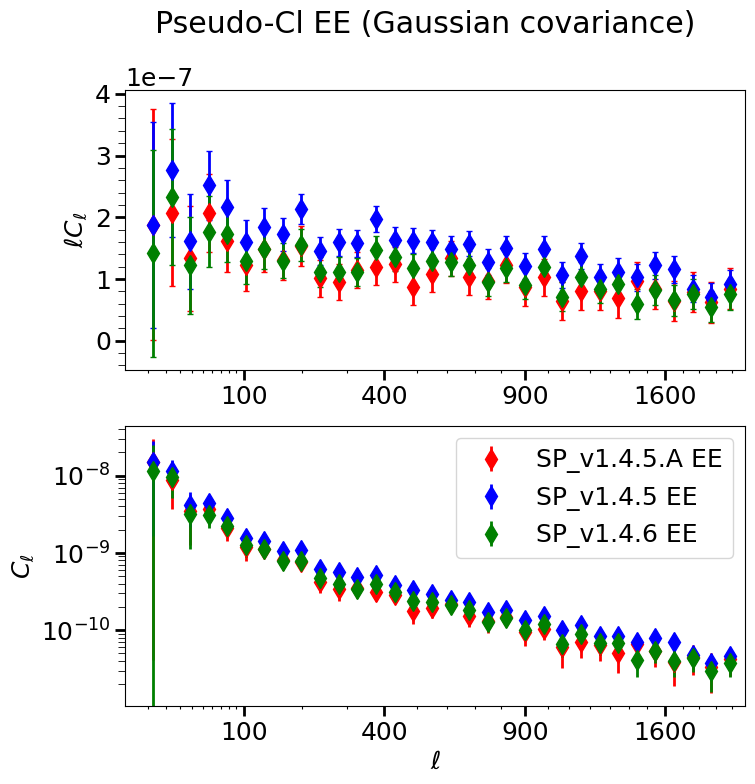

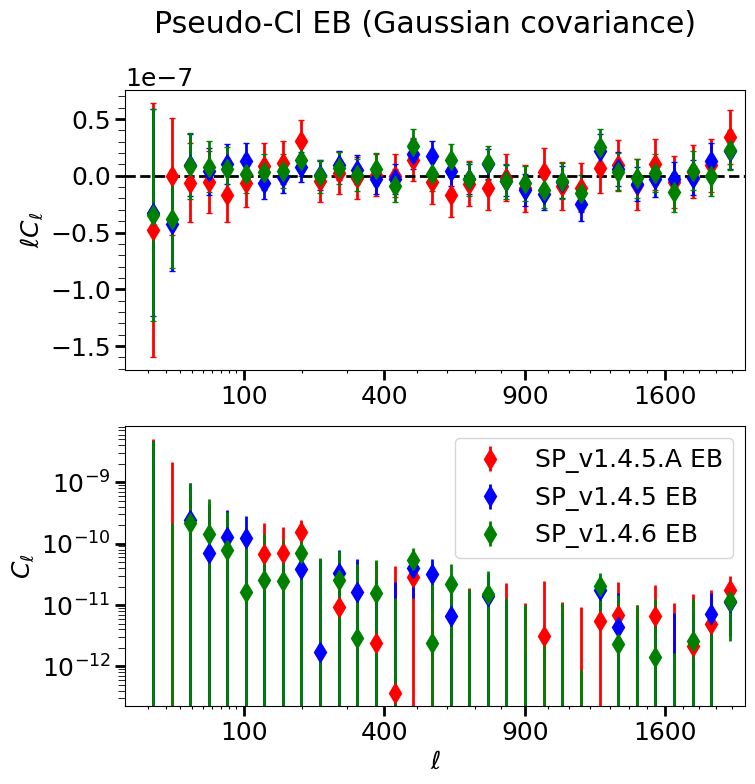

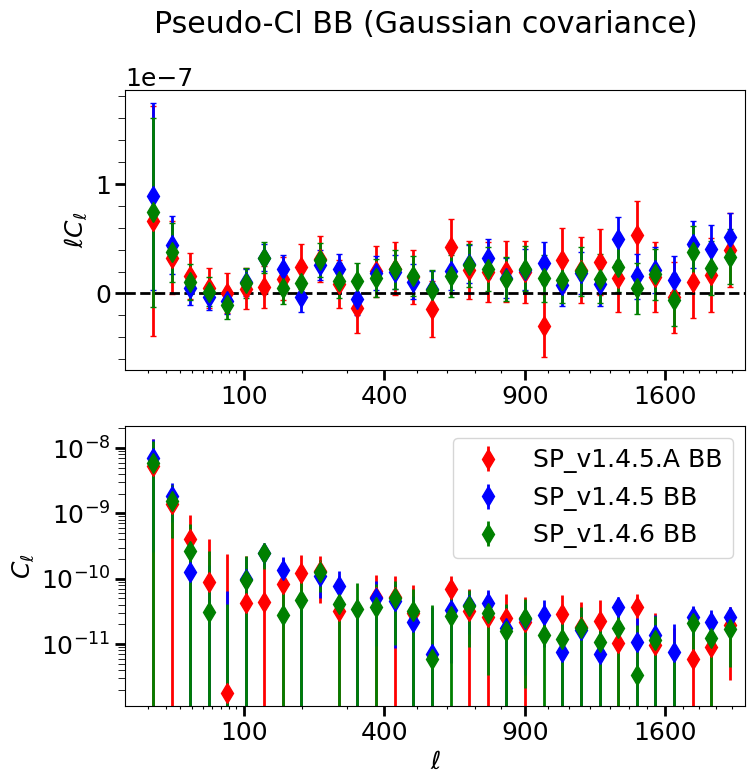

In [3]:
cv.plot_pseudo_cl() #Loads c_ells in cv object

In [4]:
def get_chi2_and_pte(data_vector, cov, verbose=True):
    """
    Calculate chi2 and pte for a given data vector and covariance matrix.
    """
    # Calculate chi2
    chi2 = data_vector @ np.linalg.inv(cov) @ data_vector
    if verbose:
        print(f"Chi2: {chi2:.4f}")
    
    #Calculate the reduced chi^2
    dof = len(data_vector)
    reduced_chi2 = chi2 / dof
    if verbose:
        print(f"Reduced Chi2: {reduced_chi2:.4f}")
    
    # Calculate pte
    pte = 1 - stats.chi2.cdf(chi2, dof)
    if verbose:
        print(f"PTE: {pte:.4f}")
    
    return chi2, reduced_chi2, pte

In [5]:
header = (
        "| Root | $\chi^2$ (EB) | $\chi^2$ (EB) / dof | p-val (EB)| $\chi^2$ (BB) | $\chi^2$ (BB) / dof | p-val (BB) |\n"
        "|------|----------------|------------|---------------|------------|------------------|--------------|\n"
    )

rows = []

for key in cv._pseudo_cls.keys():
    print(f"Key: {key}")
    row = f"| `{key}` "
    print("Metrics for EB pseudo cells:")
    data_vector = cv._pseudo_cls[key]["pseudo_cl"]["EB"]
    cov = cv._pseudo_cls[key]["cov"]["COVAR_EB_EB"].data
    chi2, reduced_chi2, pte = get_chi2_and_pte(data_vector, cov)
    row += f"| {chi2:.4f} | {reduced_chi2:.4f} | {pte:.4f} "

    print("Metrics for BB pseudo cells:")
    data_vector = cv._pseudo_cls[key]["pseudo_cl"]["BB"]
    cov = cv._pseudo_cls[key]["cov"]["COVAR_BB_BB"].data
    chi2, reduced_chi2, pte = get_chi2_and_pte(data_vector, cov)
    row += f"| {chi2:.4f} | {reduced_chi2:.4f} | {pte:.4f} |"
    rows.append(row)

# Display in Jupyter
display(Markdown(header + "\n".join(rows)))

Key: SP_v1.4.5.A
Metrics for EB pseudo cells:
Chi2: 9.8519
Reduced Chi2: 0.3079
PTE: 0.9999
Metrics for BB pseudo cells:
Chi2: 23.1080
Reduced Chi2: 0.7221
PTE: 0.8749
Key: SP_v1.4.5
Metrics for EB pseudo cells:
Chi2: 19.7087
Reduced Chi2: 0.6159
PTE: 0.9561
Metrics for BB pseudo cells:
Chi2: 63.0035
Reduced Chi2: 1.9689
PTE: 0.0009
Key: SP_v1.4.6
Metrics for EB pseudo cells:
Chi2: 14.6649
Reduced Chi2: 0.4583
PTE: 0.9963
Metrics for BB pseudo cells:
Chi2: 34.1707
Reduced Chi2: 1.0678
PTE: 0.3638


| Root | $\chi^2$ (EB) | $\chi^2$ (EB) / dof | p-val (EB)| $\chi^2$ (BB) | $\chi^2$ (BB) / dof | p-val (BB) |
|------|----------------|------------|---------------|------------|------------------|--------------|
| `SP_v1.4.5.A` | 9.8519 | 0.3079 | 0.9999 | 23.1080 | 0.7221 | 0.8749 |
| `SP_v1.4.5` | 19.7087 | 0.6159 | 0.9561 | 63.0035 | 1.9689 | 0.0009 |
| `SP_v1.4.6` | 14.6649 | 0.4583 | 0.9963 | 34.1707 | 1.0678 | 0.3638 |

In [2]:
redshift_distr = np.loadtxt('/n17data/mkilbing/astro/data/CFIS/v1.0/nz/dndz_SP_A.txt')
z, dndz = redshift_distr[:, 0], redshift_distr[:, 1]

In [3]:
#Compute theory Cl'set
h = 0.7
Oc = 0.25
Ob = 0.05

pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2,
                                    NonLinear=camb.model.NonLinear_both, WantTransfer=True)

nside = 1024
lmax = 2*nside

#getthe expected cl's from CAMB
pars.min_l = 1
pars.set_for_lmax(lmax)
pars.SourceWindows = [
    camb.sources.SplinedSourceWindow(z=z, W=dndz, source_type='lensing')
]
theory_cls = camb.get_results(pars).get_source_cls_dict(lmax=lmax, raw_cl=True)

In [6]:
best_fit_axel = np.load('/n17data/guinot/CFIS_3500/CFIS_1.4.5/inference/plots_nautilus_SP_v1_full_model_no_B_IA_opti_scale/best_model_cell_nautilus_SP_v1_full_model_no_B_IA_opti_scale.npy')

In [7]:
ell, cl_best_fit = best_fit_axel[0], best_fit_axel[1]

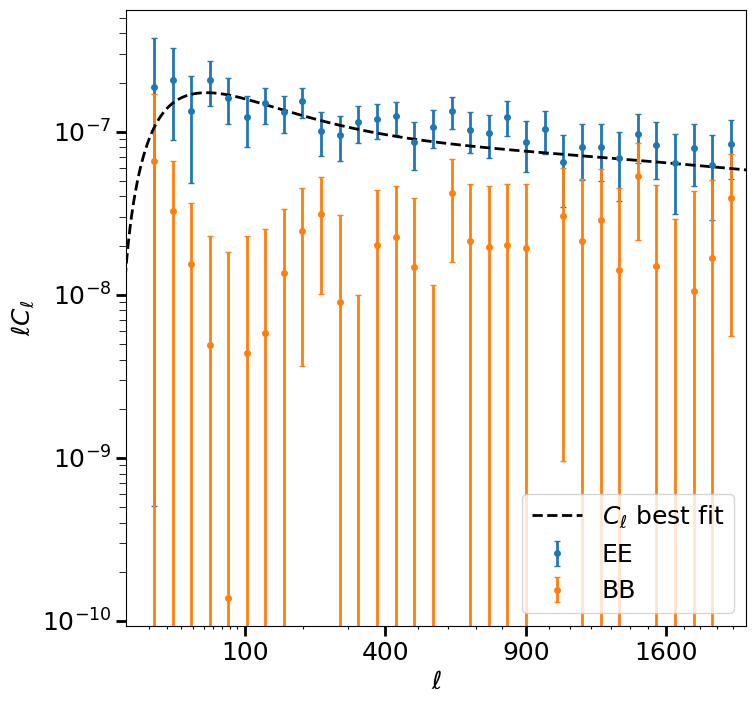

In [8]:
import healpy as hp
import utils
import matplotlib.scale as mscale

mscale.register_scale(utils.SquareRootScale)

nside = 1024
lmax = 2*nside
l = np.arange(lmax+1)
pw = hp.pixwin(nside, lmax=lmax)

pseudo_cl_glass = cv._pseudo_cls['SP_v1.4.5.A']['pseudo_cl']
cov_cl_glass = cv._pseudo_cls['SP_v1.4.5.A']['cov']

ell_eff = pseudo_cl_glass['ELL']

fig, ax = plt.subplots(figsize=(8, 8))

ax.errorbar(ell_eff, ell_eff*pseudo_cl_glass['EE'], yerr=ell_eff*np.sqrt(np.diag(cov_cl_glass["COVAR_EE_EE"].data)), fmt='o', capsize=2, markersize=4, label='EE')
ax.errorbar(ell_eff, ell_eff*pseudo_cl_glass['BB'], yerr=ell_eff*np.sqrt(np.diag(cov_cl_glass["COVAR_BB_BB"].data)), fmt='o', capsize=2, markersize=4, label='BB')
#ax.plot(l, l*theory_cls['W1xW1'], label=r'$C_\ell$ theory', c='k', ls='--')
ax.plot(ell, ell*cl_best_fit, label=r'$C_\ell$ best fit', c='k', ls='--')

ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell C_\ell$')

ax.set_xlim(ell_eff.min()-10, ell_eff.max()+100)
ax.set_xscale('squareroot')
ax.set_xticks(np.array([100, 400, 900, 1600]))
ax.minorticks_on()
ax.tick_params(axis='x', which='minor', length=2, width=0.8)
minor_ticks = [i*10 for i in range(1, 10)] + [i*100 for i in range(1, 21)]
ax.xaxis.set_ticks(minor_ticks, minor=True)

ax.set_yscale('log')

plt.legend()
plt.show()

## SP_v1.4.5

In [5]:
#PTE EB SP_v1.4.5
data_vector = cv._pseudo_cls["SP_v1.4.5.A"]["pseudo_cl"]["EB"][3:-12]
cov = cv._pseudo_cls["SP_v1.4.5.A"]["cov"]["COVAR_EB_EB"].data[3:-12, 3:-12]

In [6]:
get_chi2_and_pte(data_vector, cov)

Chi2: 5.9658
Reduced Chi2: 0.3509
PTE: 0.9934


(5.9658166359500795, 0.3509303903500047, 0.9934124099184408)

In [7]:
#PTE BB SP_v1.4.5
data_vector = cv._pseudo_cls["SP_v1.4.5.A"]["pseudo_cl"]["BB"][:]
cov = cv._pseudo_cls["SP_v1.4.5.A"]["cov"]["COVAR_BB_BB"].data[:, :]

In [8]:
get_chi2_and_pte(data_vector, cov)

Chi2: 23.1080
Reduced Chi2: 0.7221
PTE: 0.8749


(23.10803684187021, 0.722126151308444, 0.8748618301515859)

## SP_v1.4.5_leak_corr

In [9]:
#PTE EB SP_v1.4.5
data_vector = cv._pseudo_cls["SP_v1.4.5_intermediate"]["pseudo_cl"]["EB"]
cov = cv._pseudo_cls["SP_v1.4.5_intermediate"]["cov"]["COVAR_EB_EB"].data

In [10]:
get_chi2_and_pte(data_vector, cov)

Chi2: 20.9722
Reduced Chi2: 0.6554
PTE: 0.9323


(20.97219165111411, 0.6553809890973159, 0.9322719339092785)

In [11]:
# PTE BB SP_v1.4.5_leak_corr
data_vector = cv._pseudo_cls["SP_v1.4.5_intermediate"]["pseudo_cl"]["BB"][:]
cov = cv._pseudo_cls["SP_v1.4.5_intermediate"]["cov"]["COVAR_BB_BB"].data[:, :]

In [12]:
get_chi2_and_pte(data_vector, cov)

Chi2: 40.3352
Reduced Chi2: 1.2605
PTE: 0.1480


(40.33515487940795, 1.2604735899814985, 0.14803821393657934)

## SP_v1.4.1

In [13]:
#PTE EB SP_v1.4.5
data_vector = cv._pseudo_cls["SP_v1.4.5_bright"]["pseudo_cl"]["EB"]
cov = cv._pseudo_cls["SP_v1.4.5_bright"]["cov"]["COVAR_EB_EB"].data

In [14]:
get_chi2_and_pte(data_vector, cov)

Chi2: 15.9803
Reduced Chi2: 0.4994
PTE: 0.9919


(15.980318554834675, 0.4993849548385836, 0.9918574295262937)

In [15]:
#PTE BB SP_v1.4.5
data_vector = cv._pseudo_cls["SP_v1.4.5_bright"]["pseudo_cl"]["BB"][:]
cov = cv._pseudo_cls["SP_v1.4.5_bright"]["cov"]["COVAR_BB_BB"].data[:, :]

In [16]:
get_chi2_and_pte(data_vector, cov)

Chi2: 29.0115
Reduced Chi2: 0.9066
PTE: 0.6186


(29.011536180654744, 0.9066105056454608, 0.6185772830154228)

In [90]:
get_chi2_and_pte(data_vector[1:-12], cov[1:-12, 1:-12])

Chi2: 26.4131
Reduced Chi2: 1.3902
PTE: 0.1191


(np.float64(26.413105945441888),
 np.float64(1.390163470812731),
 np.float64(0.11908387555743039))

In [79]:
cov_141 = cv._pseudo_cls["SP_v1.4.1"]["cov"]["COVAR_BB_BB"].data
cov_145 = cv._pseudo_cls["SP_v1.4.5"]["cov"]["COVAR_BB_BB"].data

data_vector_sim = np.load("/home/guerrini/random_stuff/cl.npy")
cov_141_sim = np.load("/home/guerrini/random_stuff/cov_cl.npy")
cov_145_sim = np.load("/home/guerrini/random_stuff/cov_cl_1.4.5.npy")

corr_141 = np.array(
    [[1/(cov_141[i,i]*cov_141[j,j]) for i in range(32)] for j in range(32)]
)
corr_141 = cov_141*np.sqrt(corr_141)

corr_145 = np.array(
    [[1/(cov_145[i,i]*cov_145[j,j]) for i in range(32)] for j in range(32)]
)
corr_145 = cov_145*np.sqrt(corr_145)

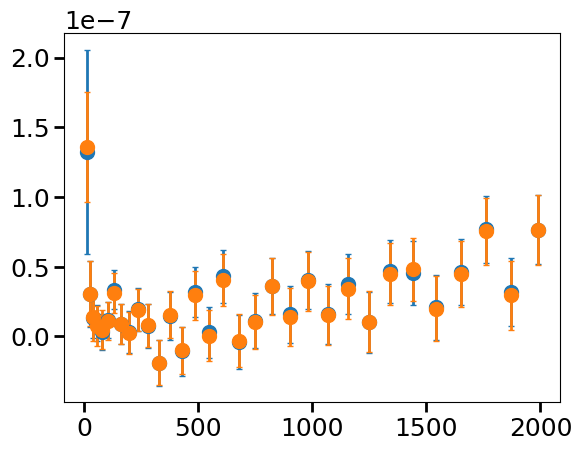

In [84]:
ell = cv._pseudo_cls["SP_v1.4.1"]["pseudo_cl"]["ELL"]

plt.figure()

plt.errorbar(ell, ell*data_vector, yerr=ell*np.sqrt(np.diag(cov_141)), fmt='o', label='SP_v1.4.1', capsize=2)
plt.errorbar(ell, ell*data_vector_sim[3], yerr=ell*np.sqrt(np.diag(cov_141_sim[3])), fmt='o', label='SP_v1.4.1_sim', capsize=2)


plt.show()

In [81]:
data_vector_sim.shape

(4, 32)

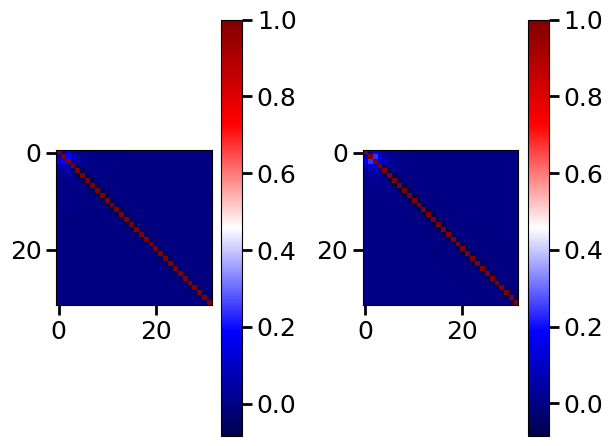

In [39]:
plt.figure()

plt.subplot(121)

plt.imshow(corr_141, cmap='seismic')
plt.colorbar()

plt.subplot(122)

plt.imshow(corr_145, cmap='seismic')
plt.colorbar()

plt.tight_layout()
plt.show()

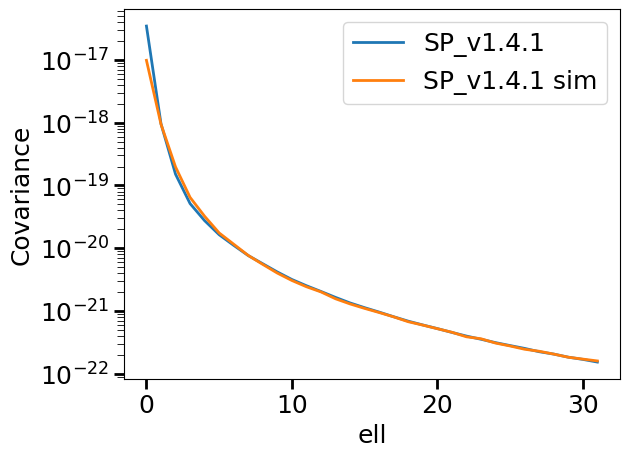

In [53]:
plt.figure()

plt.plot(np.diag(cov_141), label="SP_v1.4.1")
#plt.plot(np.diag(cov_145), label="SP_v1.4.5")
plt.plot(np.diag(cov_141_sim[3]), label="SP_v1.4.1 sim")
#plt.plot(np.diag(cov_145_sim[3]), label="SP_v1.4.5 sim")

plt.legend()
plt.xlabel("ell")
plt.ylabel("Covariance")

plt.yscale("log")

plt.show()

In [56]:
cov_141_sim[3].shape

(32, 32)

In [61]:
n_sims = 8000
n_dv = 32
hartlap_factor = (n_sims-n_dv-2)/(n_sims-1)
print(hartlap_factor)

0.9958744843105388


In [71]:
data_vector @ np.linalg.inv(cov_141_sim[3]) @ data_vector

np.float64(72.76617421925721)